# How Rap Got Stupider: A Chronological Lyrical Analysis
### Measuring the Dumbing-Down of Hip-Hop, 1989–2024

The conventional story is that hip-hop "evolved" — that it grew more diverse, more mainstream, more culturally dominant. This analysis tells a different story. Measured against its own output, charting rap has gotten significantly worse on almost every meaningful lyrical dimension: simpler vocabulary, less structural craft, narrower themes, and an accelerating obsession with a tiny set of topics — money, drugs, and self-aggrandizement.

**Research questions:**
- Has lyrical complexity — vocabulary size, word diversity, rhyme craft — increased or declined over 35 years of chart rap?
- Are rappers becoming more narcissistic? What do the pronoun trends say?
- Has the genre abandoned political and social content in favor of wealth and drugs? By how much?
- What words actually define each era of hip-hop? Are they getting more or less interesting?

**Dataset:** Billboard Hot Rap Songs — top 50 charting songs per year (1989–2024), ~1,789 songs total after filtering. By definition, the most commercially successful rap each year.

**Pipeline overview:**
1. Load the ranked chart dataset with lyrics
2. Standardize and filter out songs with no lyrics
3. Clean raw lyric text (strip structural tags, punctuation)
4. Extract chronological fields (year, decade)
5. Compute per-song metrics: word count, lexical diversity, pronoun rates, thematic keyword rates, rhyme structure
6. Summarize by year and 5-year period
7. Visualize trends across 35 years of chart history
8. Surface the most-repeated words of each era


---
## 1 · Imports and Setup

Standard analysis stack. `pandas` and `numpy` for data manipulation, `matplotlib` for charting, `re` and `Counter` for text processing. The `pronouncing` library gives access to the CMU pronunciation dictionary for phonetic rhyme detection — a more reliable measure of craft than simple word matching. NLTK stopwords are loaded if available, with a hardcoded fallback so the notebook runs regardless.


In [104]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import re
from collections import Counter
from pathlib import Path

# Rhyme analysis package (CMU pronunciation dictionary)
try:
    import pronouncing
    PRONOUNCING_AVAILABLE = True
except ImportError:
    pronouncing = None
    PRONOUNCING_AVAILABLE = False

# Optional: nltk for stopwords (the notebook works without it)
try:
    import nltk
    nltk.download("stopwords", quiet=True)
    from nltk.corpus import stopwords
    STOPWORDS = set(stopwords.words("english"))
    print("nltk stopwords loaded.")
except ImportError:
    # Minimal fallback stopword list
    STOPWORDS = {
        "the", "a", "an", "and", "or", "but", "in", "on", "at", "to",
        "for", "of", "with", "is", "it", "that", "this", "was", "are",
        "be", "has", "have", "had", "do", "does", "did", "not", "so",
        "if", "from", "by", "as", "he", "she", "they", "we", "you",
        "i", "me", "my", "your", "his", "her", "its", "our", "them",
        "been", "will", "would", "could", "should", "can", "just",
        "than", "then", "when", "what", "who", "how", "all", "no",
        "up", "out", "about", "more", "some", "very", "am", "were",
    }
    print("nltk not installed — using a small built-in stopword list.")

if PRONOUNCING_AVAILABLE:
    print("pronouncing loaded for rhyme analysis.")
else:
    print("pronouncing not installed — rhyme analysis cells will fail until installed.")

# Display settings
pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 100)

# Plot style
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

# Shared chart smoothing window (years)
SMOOTH_WINDOW = 3

print("Setup complete.")

nltk stopwords loaded.
pronouncing loaded for rhyme analysis.
Setup complete.


---
## 2 · Load Data

The dataset was built from a three-tier source ladder to guarantee 50 ranked songs per year from 1989–2025. These are the songs the market rewarded most — the commercial peak of each year.

| Tier | Source | Years |
|------|--------|-------|
| 1 | Billboard Hot Rap Songs chart | 1989–1990, 2013–2025 |
| 2 | Billboard Year-End Hot 100 filtered to rap artists | 1991–2012 (supplement) |
| 3 | Curated hip-hop lyrics dataset | Gap-filler for remaining slots |

**File:** `data/raw/billboard_rap_50_source_ladder.csv` — 1,850 rows (50 songs × 37 years)

**Key columns:** `year`, `overall_rank`, `artist`, `title`, `lyrics`, `ranking_source`, `ranking_tier`, `lyrics_available`

Note: 2025 is excluded from all analysis — insufficient lyrics coverage at time of collection.


In [105]:
DATA_PATH = Path("data/raw/billboard_rap_50_source_ladder.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. "
        "Run scripts/build_billboard_rap_50.py first."
    )

print(f"Loading: {DATA_PATH}")
df_raw = pd.read_csv(DATA_PATH, encoding="utf-8")

print(f"Shape: {df_raw.shape}")
print(f"\nColumns: {list(df_raw.columns)}")
df_raw.head(3)

Loading: data/raw/billboard_rap_50_source_ladder.csv
Shape: (1850, 9)

Columns: ['year', 'overall_rank', 'source_rank', 'artist', 'title', 'ranking_source', 'ranking_tier', 'lyrics', 'lyrics_available']


,year,overall_rank,source_rank,artist,title,ranking_source,ranking_tier,lyrics,lyrics_available
0,1989,1,1.0,The Stop The Violence Movement,Self Destruction,billboard_hot_rap_songs,1,"[Intro: Malcolm X]\nWe all agree, tonight—all of the speakers have agreed that America has a very serious problem. N...",True
1,1989,2,2.0,De La Soul,"Me, Myself And I",billboard_hot_rap_songs,1,"[Intro: Ohio Players]\n(Say it now)\n\n[Verse 1: Dove]\nMirror, mirror on the wall\nTell me, mirror, what is wrong?\...",True
2,1989,3,3.0,Young M.C.,Bust A Move,billboard_hot_rap_songs,1,this heres a tale for all the fellas tryin to do what those ladies tell us get shot down cause ya overzealous play ...,True


---
## Data Sources & Limitations

**Data Collection Strategy:** This dataset was assembled from a **3-tier source ladder** spanning 1989–2025, but the notebook analysis covers **1989–2024** — 2025 is still incomplete.

| Years | Primary Source | Notes |
|-------|---|---|
| 1989–1990, 2013–2025 | Billboard Hot Rap Songs | Official chart; ~25–50 entries/year |
| 1991–2012 | Billboard Hot 100 (filtered to rap artists) | Gap filler; songs charting cross-genre |
| Throughout | Curated fallback (lyrics library) | Fills remaining slots; used selectively |

**Known Limitations:**
- **1989 data sparsity:** Only ~19 songs from the official Billboard chart exist for this year. The remaining ~31 slots are filled from a lyrics library, causing some artists (e.g., 3rd Bass, 13 entries) to be overrepresented.
- **Lower-confidence early word frequencies (1989–1993):** Section 12 now includes this period, but it is explicitly labeled **Lower Confidence** because sparse/imbalanced early-year coverage can distort top-word counts.
- **1991–2012 secondary source:** Hot 100 entries may include songs that charted primarily as pop/R&B crossovers.
- **2025 removed entirely:** Only 1 charted song had available lyrics at collection time.

The two charts below show **songs retained per year** and **unique artists per year**. Note how artist diversity — a rough proxy for how many distinct voices the market supported — trends over time. Consolidation around fewer artists is itself a symptom worth tracking.

**All notebook outputs cover 1989–2024 only.** Section 12 includes 1989–1993, but flags it as **Lower Confidence**.


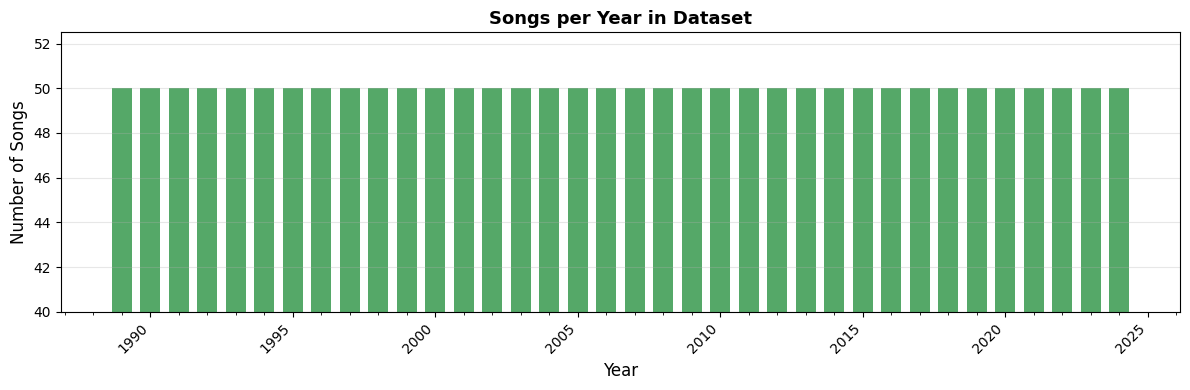

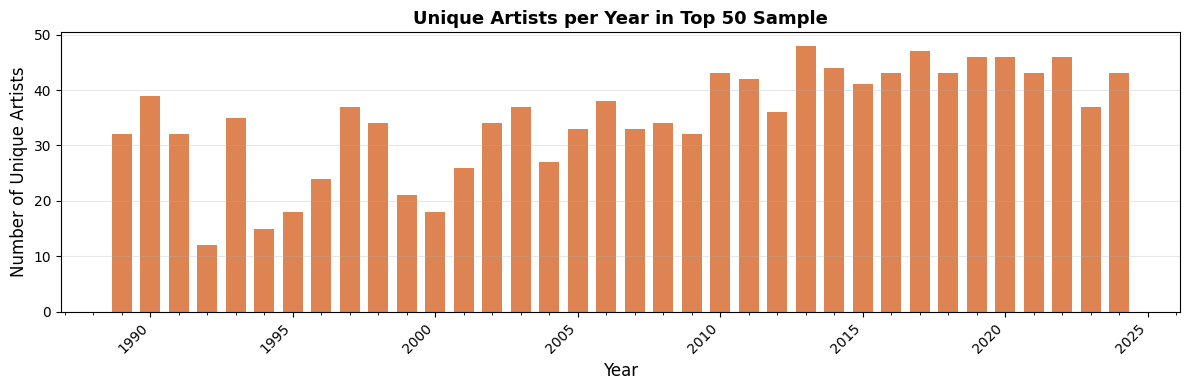

Unique artist diversity in top 50 per year:
  Min: 12 (year 1992)
  Max: 48 (year 2013)
  Mean: 35.0
  Median: 36


In [106]:
# Dataset coverage and artist diversity by year
coverage_by_year = (
    df_raw[df_raw["year"] != 2025]
    .groupby("year")
    .agg(song_count=("title", "size"), unique_artists=("artist", pd.Series.nunique))
    .reset_index()
    .sort_values("year")
)

# Song count per year retained in the raw source-ladder dataset
_, ax = plt.subplots(figsize=(12, 4))
ax.bar(coverage_by_year["year"], coverage_by_year["song_count"], color="#55A868", width=0.7)
ax.set_title("Songs per Year in Dataset", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Songs")
ax.set_ylim(bottom=40)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Unique artist count per year
_, ax = plt.subplots(figsize=(12, 4))
ax.bar(coverage_by_year["year"], coverage_by_year["unique_artists"], color="#DD8452", width=0.7)
ax.set_title("Unique Artists per Year in Top 50 Sample", fontsize=13, fontweight="bold")
ax.set_xlabel("Year")
ax.set_ylabel("Number of Unique Artists")
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Unique artist diversity in top 50 per year:")
print(f"  Min: {coverage_by_year['unique_artists'].min()} (year {coverage_by_year.loc[coverage_by_year['unique_artists'].idxmin(), 'year']:.0f})")
print(f"  Max: {coverage_by_year['unique_artists'].max()} (year {coverage_by_year.loc[coverage_by_year['unique_artists'].idxmax(), 'year']:.0f})")
print(f"  Mean: {coverage_by_year['unique_artists'].mean():.1f}")
print(f"  Median: {coverage_by_year['unique_artists'].median():.0f}")

---
## 3 · Standardize Column Names

The `find_column()` helper normalizes inconsistent column naming across data sources. Everything is mapped to a consistent four-column schema:

| Standardized name | Meaning |
|-------------------|---------|
| `artist` | Performing artist(s) |
| `title` | Song title |
| `lyrics` | Full lyric text |
| `release_year` | Chart year (four-digit integer) |

Rows with missing or blank lyrics are dropped — songs that left no lyrical record don't contribute to the analysis. Within-year duplicate artist–title pairs are deduplicated, keeping the higher-ranked entry. Cross-year duplicates are preserved: a song that charted in multiple years contributes to each year independently, which is accurate for trend analysis.


In [107]:
def find_column(df, candidates):
    """Return the first column whose lowercase name matches any candidate."""
    lower_cols = {c.lower().strip(): c for c in df.columns}
    for candidate in candidates:
        if candidate in lower_cols:
            return lower_cols[candidate]
    return None

col_map = {}

# Artist
artist_col = find_column(df_raw, ["artist", "artist_name", "performer", "rapper"])
if artist_col:
    col_map[artist_col] = "artist"
else:
    print("WARNING: Could not find an artist column. Creating a placeholder.")
    df_raw["artist"] = "Unknown"

# Title
title_col = find_column(df_raw, ["title", "song", "song_name", "track", "track_name", "name"])
if title_col:
    col_map[title_col] = "title"
else:
    print("WARNING: Could not find a title column. Creating a placeholder.")
    df_raw["title"] = "Untitled"

# Lyrics
lyrics_col = find_column(df_raw, ["lyrics", "lyric", "text", "song_lyrics"])
if lyrics_col:
    col_map[lyrics_col] = "lyrics"
else:
    raise ValueError(
        "Could not find a lyrics column. "
        f"Available columns: {list(df_raw.columns)}"
    )

# Year
year_col = find_column(df_raw, [
    "year", "release_year", "release_date", "date", "album_year",
    "album_date", "album_release_date",
])
if year_col:
    col_map[year_col] = "release_year"
else:
    print("WARNING: Could not find a year/date column. Creating a placeholder (NaN).")
    df_raw["release_year"] = np.nan

df = df_raw.rename(columns=col_map)
df = df.loc[:, ~df.columns.duplicated()].copy()  # drop duplicate cols

print("Column mapping applied:")
for old, new in col_map.items():
    print(f"  {old} -> {new}")

# Keep only the columns we need (plus any extras the user might want later)
required = ["artist", "title", "lyrics", "release_year"]
extra = [c for c in df.columns if c not in required]
df = df[required + extra].copy()

# Normalize year and remove incomplete 2025 data from the notebook pipeline
df["release_year"] = pd.to_numeric(df["release_year"], errors="coerce")
before = len(df)
df = df[df["release_year"].ne(2025)].copy()
print(f"\nDropped {before - len(df)} rows from 2025 (incomplete year).")

# Drop rows without lyrics
before = len(df)
df = df.dropna(subset=["lyrics"])
df = df[df["lyrics"].str.strip().astype(bool)]
print(f"Dropped {before - len(df)} rows with empty/missing lyrics.")

# Remove duplicates within the same chart year (keep highest-ranked entry)
# We preserve cross-year duplicates so chronological analysis stays intact
before = len(df)
df = df.drop_duplicates(subset=["release_year", "artist", "title"], keep="first")
print(f"Dropped {before - len(df)} within-year duplicate artist–title pairs.")

df = df.reset_index(drop=True)
print(f"\nDataset ready: {df.shape[0]} songs, {df.shape[1]} columns.")
df.head()

Column mapping applied:
  artist -> artist
  title -> title
  lyrics -> lyrics
  year -> release_year

Dropped 50 rows from 2025 (incomplete year).
Dropped 12 rows with empty/missing lyrics.
Dropped 0 within-year duplicate artist–title pairs.

Dataset ready: 1788 songs, 9 columns.


,artist,title,lyrics,release_year,overall_rank,source_rank,ranking_source,ranking_tier,lyrics_available
0,The Stop The Violence Movement,Self Destruction,"[Intro: Malcolm X]\nWe all agree, tonight—all of the speakers have agreed that America has a very serious problem. N...",1989,1,1.0,billboard_hot_rap_songs,1,True
1,De La Soul,"Me, Myself And I","[Intro: Ohio Players]\n(Say it now)\n\n[Verse 1: Dove]\nMirror, mirror on the wall\nTell me, mirror, what is wrong?\...",1989,2,2.0,billboard_hot_rap_songs,1,True
2,Young M.C.,Bust A Move,this heres a tale for all the fellas tryin to do what those ladies tell us get shot down cause ya overzealous play ...,1989,3,3.0,billboard_hot_rap_songs,1,True
3,Public Enemy,Fight The Power,"[Intro: Thomas 'TNT' Todd]\nYet our best-trained, best-educated, best-equipped, best-prepared troops refuse to fight...",1989,4,4.0,billboard_hot_rap_songs,1,True
4,Slick Rick,Children's Story,"[Produced by Slick Rick]\n\n[Intro]\n(Now here's a little something that needs to be heard)\nUncle Ricky, could you ...",1989,5,6.0,billboard_hot_rap_songs,1,True


---
## 4 · Clean Lyrics

Raw lyrics from chart databases include structural markup that would pollute word-frequency analysis. The `clean_lyrics()` function:

- Lowercases everything for consistent matching
- Removes bracketed section headers (`[Chorus]`, `[Verse 1]`, `[Intro]`, etc.)
- Strips parenthetical directions and annotations
- Drops punctuation while preserving apostrophes inside contractions (*don't*, *I'm*, *can't*)
- Collapses extra whitespace

The cleaned text feeds all metric calculations. The original `lyrics` column is preserved only for line counts — line structure carries information about song construction and flow density.

Three baseline stats per song: `word_count`, `line_count`, and `avg_words_per_line`. These set the baseline for measuring how much rappers are actually saying.


In [108]:
def clean_lyrics(text):
    """Lowercase, strip section labels, collapse whitespace."""
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r"\[.*?\]", " ", text)        # remove [Chorus], [Verse 1], etc.
    text = re.sub(r"\(.*?\)", " ", text)         # remove parenthetical stage directions
    text = re.sub(r"[^\w\s']", " ", text)        # keep letters, digits, apostrophes
    text = re.sub(r"\s+", " ", text).strip()     # collapse whitespace
    return text


df["lyrics_clean"] = df["lyrics"].apply(clean_lyrics)

df["word_count"] = df["lyrics_clean"].str.split().str.len().fillna(0).astype(int)

# Line count from the ORIGINAL lyrics (newlines matter for flow)
df["line_count"] = df["lyrics"].apply(
    lambda t: len([ln for ln in str(t).splitlines() if ln.strip()])
)

df["avg_words_per_line"] = (df["word_count"] / df["line_count"].replace(0, np.nan)).round(2)

print("Lyrics cleaned.")
print(f"  Median word count : {df['word_count'].median():.0f}")
print(f"  Median line count : {df['line_count'].median():.0f}")
df[["artist", "title", "word_count", "line_count", "avg_words_per_line"]].head()

Lyrics cleaned.
  Median word count : 496
  Median line count : 40


,artist,title,word_count,line_count,avg_words_per_line
0,The Stop The Violence Movement,Self Destruction,1063,163,6.52
1,De La Soul,"Me, Myself And I",426,104,4.10
2,Young M.C.,Bust A Move,616,1,616.00
3,Public Enemy,Fight The Power,649,178,3.65
4,Slick Rick,Children's Story,598,78,7.67


---
## 5 · Chronological Fields

`release_year` is parsed and validated — any year outside the rap era (1970 to present) is discarded. A `decade` label is derived from the year (`1989` → `1980s`, `2003` → `2000s`, etc.).

Songs with unknown years are excluded from time-series and decade analyses. The dataset is sorted chronologically so all downstream groupby operations run in correct temporal order.


In [109]:
def extract_year(value):
    """Pull a four-digit year from a string, int, or float."""
    if pd.isna(value):
        return np.nan
    match = re.search(r"(19[6-9]\d|20[0-2]\d)", str(value))
    return int(match.group(1)) if match else np.nan


df["release_year"] = df["release_year"].apply(extract_year)

# Filter to plausible rap-era years (1970–current year)
current_year = pd.Timestamp.now().year
valid_mask = df["release_year"].between(1970, current_year)
dropped = (~valid_mask & df["release_year"].notna()).sum()
if dropped:
    print(f"Dropping {dropped} songs with years outside 1970–{current_year}.")
df.loc[~valid_mask, "release_year"] = np.nan

# Decade column
df["decade"] = (df["release_year"] // 10 * 10).astype("Int64").astype(str) + "s"
df.loc[df["release_year"].isna(), "decade"] = "Unknown"

# Sort chronologically (unknown years go to the end)
df = df.sort_values(["release_year", "artist", "title"], na_position="last").reset_index(drop=True)

print("\nSongs per decade:")
print(df["decade"].value_counts().sort_index())
print(f"\nDataset sorted by year. First song: {df.loc[0, 'artist']} — {df.loc[0, 'title']} ({int(df.loc[0, 'release_year'])})")
df[["artist", "title", "release_year", "decade"]].head(10)


Songs per decade:
decade
1980s     50
1990s    498
2000s    495
2010s    498
2020s    247
Name: count, dtype: int64

Dataset sorted by year. First song: 2 Live Crew — Me So Horny (1989)


,artist,title,release_year,decade
0,2 Live Crew,Me So Horny,1989.0,1980s
1,38 special,second chance,1989.0,1980s
2,3Rd Bass,brooklyn-queens,1989.0,1980s
3,3Rd Bass,flippin-off-the-wall-like-lucy-ball,1989.0,1980s
4,3Rd Bass,monte-hall,1989.0,1980s
5,3Rd Bass,oval-office,1989.0,1980s
6,3Rd Bass,product-of-the-environment,1989.0,1980s
7,3Rd Bass,sons-of-3rd-bass,1989.0,1980s
8,3Rd Bass,soul-in-the-soul,1989.0,1980s
9,3Rd Bass,steppin-to-the-a-m,1989.0,1980s


---
## 6 · Lyric Metrics

Per-song metrics are computed across five categories. All rates are normalized by word count so songs of different lengths remain comparable.

**Vocabulary complexity** — the most direct measure of lyrical sophistication
- `word_count`: total tokens in `lyrics_clean`
- `line_count`: non-empty lines in original `lyrics`
- `avg_words_per_line`: `word_count / line_count`
- `unique_words`: distinct tokens — how large a vocabulary a song draws on
- `lexical_diversity`: `unique_words / word_count` — the key richness metric. A score of 1.0 means every word used is different; lower means more repetition
- `avg_word_length`: average token length in characters

**Pronoun profiles** — who the rapper is talking about
- `pron_1s_rate`: rate of *I / me / my / mine* — individual self-focus
- `pron_1p_rate`: rate of *we / us / our* — collective identity
- `pron_2_rate`: rate of *you / your / y'all* — audience address

**Profanity**
- `profanity_rate`: matches from the `PROFANITY` set divided by total words

**Rhyme structure** — phonetic craft, measured via CMUdict
- `end_rhyme_rate`: fraction of adjacent line-ending pairs that rhyme. The primary measure of structural craft.
- `end_self_or_unknown_rate`: fraction of adjacent end pairs that repeat the same word or fall outside the pronunciation dictionary — a proxy for weak or lazy rhyming
- `internal_rhyme_rate`: fraction of lines with at least one within-line rhyme pair. Exploratory; sensitive to transcription quality.

**Thematic keyword rates** — what rap is actually about
- Rates for five dictionaries: `wealth`, `violence`, `politics`, `drugs`, `introspection`
- Each measures how much of a song's wordcount is dedicated to that theme

The keyword dictionaries are defined in the next cell and can be tuned.


In [110]:
# ── Helper ────────────────────────────────────────────────────────────

WORD_RE = re.compile(r"[a-z']+")
RHYME_KEY_CACHE = {}


def word_list(text):
    """Split cleaned lyrics into a list of words."""
    if not isinstance(text, str) or not text:
        return []
    return text.split()


def count_matches(words, target_set):
    """Count how many words in `words` appear in `target_set`."""
    return sum(1 for w in words if w in target_set)


def rate(count, total):
    """Safely compute count / total, returning 0 when total is 0."""
    return count / total if total else 0.0


def lyric_lines(text):
    """Return non-empty lyric lines from the original text."""
    if not isinstance(text, str):
        return []
    return [ln.strip() for ln in text.splitlines() if ln.strip()]


def line_words(line):
    """Extract normalized lowercase words from one lyric line."""
    return WORD_RE.findall(str(line).lower())


def rhyme_key(word):
    """Get the CMU rhyming part for a word (cached)."""
    if word in RHYME_KEY_CACHE:
        return RHYME_KEY_CACHE[word]
    phones = pronouncing.phones_for_word(word)
    key = pronouncing.rhyming_part(phones[0]) if phones else None
    RHYME_KEY_CACHE[word] = key
    return key


def words_rhyme(word_a, word_b):
    """True if two different words have the same rhyming part."""
    if not word_a or not word_b or word_a == word_b:
        return False
    key_a = rhyme_key(word_a)
    key_b = rhyme_key(word_b)
    return bool(key_a and key_b and key_a == key_b)


def compute_rhyme_metrics(lyrics_text):
    """Compute end- and internal-rhyme metrics for one song."""
    lines = lyric_lines(lyrics_text)
    if not lines:
        return pd.Series(
            {
                "end_rhyme_count": 0,
                "end_rhyme_pairs": 0,
                "end_rhyme_rate": 0.0,
                "end_self_or_unknown_pairs": 0,
                "end_self_or_unknown_rate": 0.0,
                "internal_rhyme_lines": 0,
                "internal_rhyme_rate": 0.0,
            }
        )

    # End-rhyme metric on adjacent line endings
    end_words = []
    for line in lines:
        tokens = line_words(line)
        if tokens:
            end_words.append(tokens[-1])

    end_pairs_total = max(len(end_words) - 1, 0)
    end_pairs = 0
    end_matches = 0
    end_self_or_unknown_pairs = 0

    for left, right in zip(end_words[:-1], end_words[1:]):
        left_key = rhyme_key(left)
        right_key = rhyme_key(right)

        if left == right or not left_key or not right_key:
            end_self_or_unknown_pairs += 1

        if left_key and right_key:
            end_pairs += 1
            if words_rhyme(left, right):
                end_matches += 1

    # Internal-rhyme metric at the line level
    internal_lines = 0
    for line in lines:
        tokens = line_words(line)
        if len(tokens) < 3:
            continue
        found = False
        for i in range(len(tokens) - 1):
            for j in range(i + 1, len(tokens)):
                if words_rhyme(tokens[i], tokens[j]):
                    found = True
                    break
            if found:
                break
        if found:
            internal_lines += 1

    return pd.Series(
        {
            "end_rhyme_count": end_matches,
            "end_rhyme_pairs": end_pairs,
            "end_rhyme_rate": round(rate(end_matches, end_pairs), 4),
            "end_self_or_unknown_pairs": end_self_or_unknown_pairs,
            "end_self_or_unknown_rate": round(rate(end_self_or_unknown_pairs, end_pairs_total), 4),
            "internal_rhyme_lines": internal_lines,
            "internal_rhyme_rate": round(rate(internal_lines, len(lines)), 4),
        }
    )

In [111]:
# ── Editable Dictionaries ─────────────────────────────────────────────
# Add or remove terms to tune the analysis.

PROFANITY = {
    "fuck", "shit", "bitch", "ass", "damn", "hell", "nigga", "niggas",
    "hoe", "hoes", "motherfucker", "motherfuckin", "fuckin", "fucked",
    "shitty", "bullshit", "asshole", "dick", "pussy",
}

PRONOUNS_1S = {"i", "me", "my", "mine", "i'm", "i'll", "i've", "i'd"}
PRONOUNS_1P = {"we", "us", "our", "ours", "we're", "we'll", "we've"}
PRONOUNS_2  = {"you", "your", "yours", "you're", "you'll", "you've", "yall", "y'all"}

WEALTH = {
    "money", "cash", "dollar", "dollars", "rich", "bling", "ice",
    "chain", "chains", "gold", "diamond", "diamonds", "rolex",
    "gucci", "louis", "bentley", "benz", "lambo", "ferrari",
    "mansion", "penthouse", "millionaire", "billionaire", "bank",
    "drip", "flex", "bands", "racks", "bread", "paper", "cheddar",
}

VIOLENCE = {
    "gun", "guns", "shoot", "shot", "kill", "murder", "dead", "die",
    "blood", "beef", "war", "trigger", "bullet", "bullets", "glock",
    "knife", "stab", "gang", "gangsta", "thug", "rob", "steal",
    "crime", "prison", "jail", "locked", "hustle", "trap",
}

POLITICS = {
    "freedom", "justice", "equality", "rights", "power", "revolution",
    "protest", "vote", "government", "system", "oppression", "racism",
    "police", "cops", "brutality", "poverty", "ghetto", "hood",
    "community", "struggle", "movement", "resist", "change",
    "unity", "peace", "black", "liberation", "political",
}

DRUGS = {
    "weed", "smoke", "blunt", "joint", "high", "stoned", "marijuana",
    "kush", "dope", "crack", "cocaine", "coke", "lean", "codeine",
    "pills", "pill", "xan", "xanax", "molly", "ecstasy", "acid",
    "drunk", "liquor", "hennessy", "sip", "pour", "percocet", "perc",
}

INTROSPECTION = {
    "feel", "feeling", "feelings", "soul", "heart", "pain", "cry",
    "tears", "lonely", "alone", "depressed", "depression", "anxiety",
    "mental", "therapy", "heal", "healing", "trauma", "stress",
    "pray", "prayer", "god", "faith", "hope", "dream", "dreams",
    "think", "thought", "thoughts", "mind", "remember", "memories",
}

print("Dictionaries defined.")

Dictionaries defined.


In [112]:
# ── Compute Metrics ───────────────────────────────────────────────────

if not PRONOUNCING_AVAILABLE:
    raise ImportError(
        "Install `pronouncing` to run rhyme analysis (pip install pronouncing)."
    )

words_series = df["lyrics_clean"].apply(word_list)

df["unique_words"]     = words_series.apply(lambda ws: len(set(ws)))
df["lexical_diversity"] = (df["unique_words"] / df["word_count"].replace(0, np.nan)).round(4)
df["avg_word_length"]  = words_series.apply(
    lambda ws: np.mean([len(w) for w in ws]) if ws else 0
).round(2)

# Profanity
df["profanity_count"] = words_series.apply(lambda ws: count_matches(ws, PROFANITY))
df["profanity_rate"]  = (df["profanity_count"] / df["word_count"].replace(0, np.nan)).round(4)

# Pronouns
df["pron_1s_count"] = words_series.apply(lambda ws: count_matches(ws, PRONOUNS_1S))
df["pron_1s_rate"]  = (df["pron_1s_count"] / df["word_count"].replace(0, np.nan)).round(4)

df["pron_1p_count"] = words_series.apply(lambda ws: count_matches(ws, PRONOUNS_1P))
df["pron_1p_rate"]  = (df["pron_1p_count"] / df["word_count"].replace(0, np.nan)).round(4)

df["pron_2_count"]  = words_series.apply(lambda ws: count_matches(ws, PRONOUNS_2))
df["pron_2_rate"]   = (df["pron_2_count"] / df["word_count"].replace(0, np.nan)).round(4)

# Rhyme metrics
rhyme_metrics = df["lyrics"].apply(compute_rhyme_metrics)
for col in rhyme_metrics.columns:
    df[col] = rhyme_metrics[col]

# Thematic dictionaries
for label, dictionary in [
    ("wealth",        WEALTH),
    ("violence",      VIOLENCE),
    ("politics",      POLITICS),
    ("drugs",         DRUGS),
    ("introspection", INTROSPECTION),
]:
    df[f"{label}_count"] = words_series.apply(lambda ws, d=dictionary: count_matches(ws, d))
    df[f"{label}_rate"]  = (df[f"{label}_count"] / df["word_count"].replace(0, np.nan)).round(4)

print("All metrics computed.")
df[["artist", "title", "word_count", "lexical_diversity",
    "end_rhyme_rate", "internal_rhyme_rate", "profanity_rate",
    "pron_1s_rate", "wealth_rate", "introspection_rate"]].head(10)

All metrics computed.


,artist,title,word_count,lexical_diversity,end_rhyme_rate,internal_rhyme_rate,profanity_rate,pron_1s_rate,wealth_rate,introspection_rate
0,2 Live Crew,Me So Horny,317,0.4795,0.1220,0.1961,0.0252,0.1167,0.0000,0.0095
1,38 special,second chance,356,0.2837,0.0000,1.0000,0.0000,0.0646,0.0000,0.0534
2,3Rd Bass,brooklyn-queens,455,0.5824,0.1719,0.1127,0.0044,0.0396,0.0132,0.0022
3,3Rd Bass,flippin-off-the-wall-like-lucy-ball,268,0.4478,0.0000,0.2143,0.0187,0.0410,0.0000,0.0410
4,3Rd Bass,monte-hall,505,0.5208,0.1148,0.1429,0.0000,0.0218,0.0000,0.0000
5,3Rd Bass,oval-office,670,0.4194,0.0316,0.0818,0.0000,0.0761,0.0000,0.0090
6,3Rd Bass,product-of-the-environment,756,0.4854,0.1529,0.1600,0.0000,0.0503,0.0026,0.0079
7,3Rd Bass,sons-of-3rd-bass,506,0.6067,0.1273,0.1765,0.0020,0.0178,0.0040,0.0040
8,3Rd Bass,soul-in-the-soul,606,0.5347,0.1515,0.2603,0.0033,0.0429,0.0017,0.0099
9,3Rd Bass,steppin-to-the-a-m,692,0.3931,0.0792,0.1933,0.0000,0.0434,0.0000,0.0058


---
## 7 · Period-Level Summary

All per-song metrics are averaged within each 5-year period to track evolution at a finer granularity than full decades. The periods covered are: 1989–1993, 1994–1998, 1999–2003, 2004–2008, 2009–2013, 2014–2018, and 2019–2024. This 5-year view captures regional and stylistic wave shifts that a full decade would blur.


In [113]:
# Only summarize periods with known years
df_known = df[df["decade"] != "Unknown"].copy()

# Create 5-year periods
period_bins = [1989, 1994, 1999, 2004, 2009, 2014, 2019, 2025]
period_labels = ["1989-1993", "1994-1998", "1999-2003", "2004-2008", "2009-2013", "2014-2018", "2019-2024"]
df_known["period"] = pd.cut(df_known["release_year"], bins=period_bins, labels=period_labels, right=False)

rate_cols = [
    "word_count", "line_count", "avg_words_per_line",
    "lexical_diversity", "avg_word_length",
    "profanity_rate", "end_rhyme_rate", "internal_rhyme_rate",
    "pron_1s_rate", "pron_1p_rate", "pron_2_rate",
    "wealth_rate", "violence_rate", "politics_rate",
    "drugs_rate", "introspection_rate",
]

period_summary = (
    df_known
    .groupby("period")
    .agg(
        song_count=("title", "size"),
        **{col: (col, "mean") for col in rate_cols},
    )
    .round(4)
    .sort_index()
)

print("Period-level summary (5-year blocks, 1989–2024):")
period_summary

Period-level summary (5-year blocks, 1989–2024):


,song_count,word_count,line_count,avg_words_per_line,lexical_diversity,avg_word_length,profanity_rate,end_rhyme_rate,internal_rhyme_rate,pron_1s_rate,pron_1p_rate,pron_2_rate,wealth_rate,violence_rate,politics_rate,drugs_rate,introspection_rate
period,,,,,,,,,,,,,,,,,
1989-1993,249,411.7390,33.4016,187.4109,0.4310,3.9261,0.0040,0.0500,0.5894,0.0617,0.0096,0.0408,0.0020,0.0020,0.0033,0.0013,0.0120
1994-1998,249,401.0361,23.4739,238.0834,0.4235,4.0834,0.0112,0.0650,0.6168,0.0697,0.0091,0.0458,0.0019,0.0019,0.0020,0.0011,0.0110
1999-2003,247,534.8745,29.4818,324.1142,0.3826,3.7959,0.0112,0.0398,0.6666,0.0723,0.0102,0.0515,0.0027,0.0037,0.0019,0.0020,0.0114
2004-2008,249,551.3655,20.8715,407.3073,0.3487,3.7412,0.0099,0.0247,0.7629,0.0710,0.0100,0.0473,0.0038,0.0025,0.0020,0.0022,0.0097
2009-2013,247,514.9555,23.0810,354.8644,0.3408,3.8031,0.0122,0.0177,0.7491,0.0751,0.0092,0.0445,0.0051,0.0024,0.0018,0.0024,0.0095
2014-2018,250,573.5960,78.9160,59.9350,0.3567,3.8494,0.0236,0.0445,0.2743,0.0875,0.0075,0.0358,0.0087,0.0047,0.0017,0.0042,0.0067
2019-2024,297,533.7508,76.3939,7.1751,0.3962,3.8992,0.0263,0.0477,0.2047,0.0808,0.0062,0.0327,0.0060,0.0048,0.0016,0.0022,0.0072


---
## 8 · Rhyme Analysis

This section is dedicated to rhyme trends from 1989 to 2024. It analyzes:
- **End Rhyme Rate by Year**
- **Internal Rhyme Rate by Year**
- **End Self-or-Unknown Pair Rate by Year** (how often adjacent line-ending pairs either repeat the same word or include a word missing from CMUdict)

Rhyme scheme is central to rap because it is one of the clearest signals of lyrical craft. Strong rhyme structure helps bars feel intentional, memorable, and rhythmically tight; weak rhyme structure makes verses sound flatter, repetitive, or underwritten. Unlike many other genres where melody can carry weak writing, rap exposes the writing itself, so rhyme quality matters more directly.

Rhyme scheme is also difficult in rap. Writers must keep semantic meaning, narrative flow, and rhythmic timing aligned while still finding phonetically compatible word endings and internal sound patterns. Doing that across long verses, with slang, multilingual vocabulary, and unconventional spellings, is technically demanding. That is why changes in these rhyme metrics are meaningful as proxies for craft over time.

Both rhyme curves are shown with a 3-year centered rolling average for readability.

**Methodology (phonetic):**
- Rhymes are detected with the CMU pronunciation dictionary via `pronouncing`
- End-rhyme compares adjacent line-ending words
- Internal-rhyme checks for within-line rhyme pairs
- The self/unknown metric flags adjacent line-end pairs where rhyme quality is weaker to evaluate potential reliance on repetition or out-of-dictionary terms

**Caveat:** Internal-rhyme analysis is exploratory and can be more sensitive to transcription quality, line breaks, and slang spellings than end-rhyme detection.

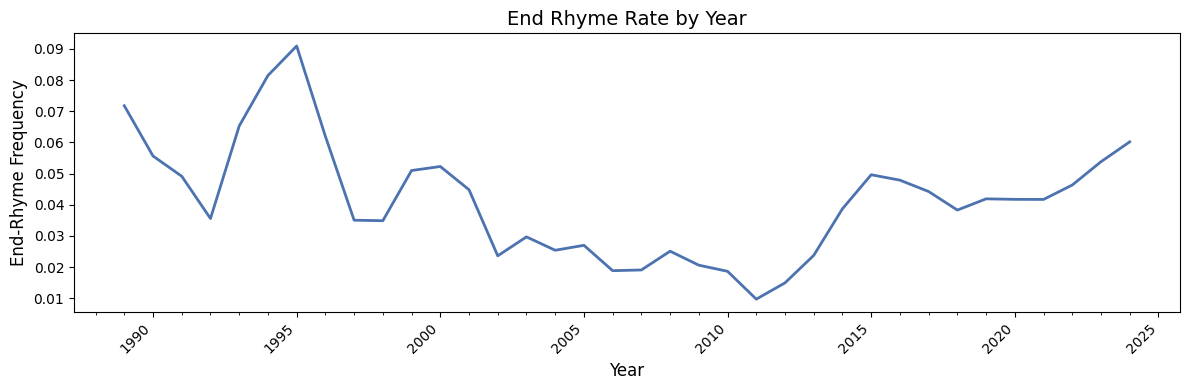

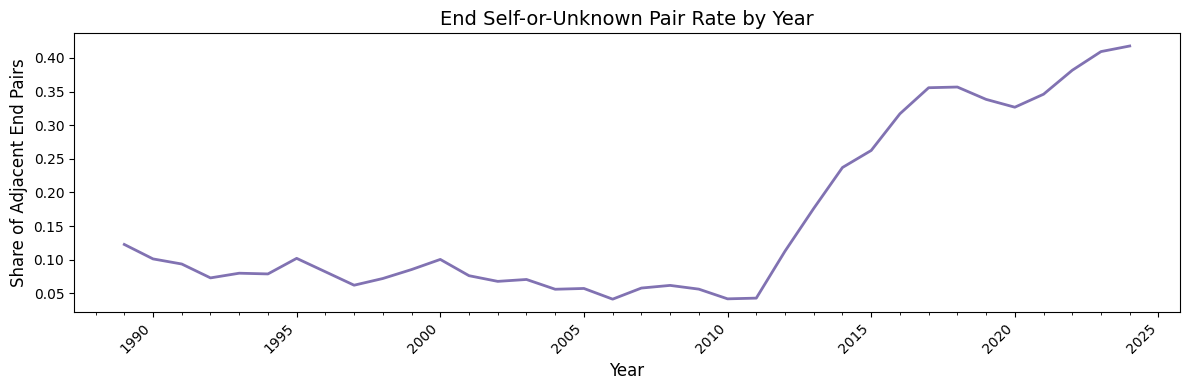

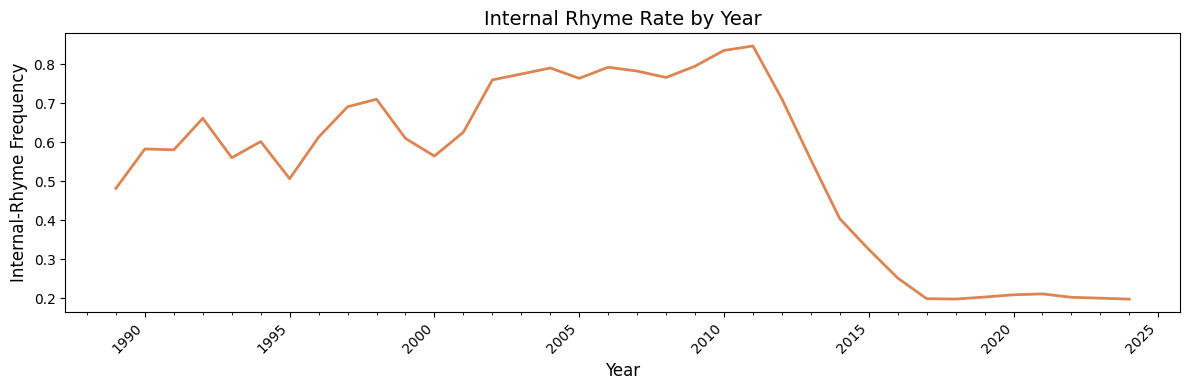

In [114]:
# Rhyme trends by year (dedicated section)
rhyme_year_summary = (
    df.dropna(subset=["release_year"])
    .groupby("release_year")
    .agg(
        end_rhyme_rate=("end_rhyme_rate", "mean"),
        internal_rhyme_rate=("internal_rhyme_rate", "mean"),
        end_self_or_unknown_rate=("end_self_or_unknown_rate", "mean"),
    )
    .sort_index()
)

rhyme_years = rhyme_year_summary.index.tolist()


def smooth_rhyme(column):
    return rhyme_year_summary[column].rolling(window=SMOOTH_WINDOW, center=True, min_periods=1).mean()


_, ax = plt.subplots(figsize=(12, 4))
ax.plot(rhyme_years, smooth_rhyme("end_rhyme_rate"), linewidth=2.0, color="#4C72B0")
ax.set_title("End Rhyme Rate by Year")
ax.set_xlabel("Year")
ax.set_ylabel("End-Rhyme Frequency")
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

_, ax = plt.subplots(figsize=(12, 4))
ax.plot(rhyme_years, smooth_rhyme("end_self_or_unknown_rate"), linewidth=2.0, color="#8172B2")
ax.set_title("End Self-or-Unknown Pair Rate by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Share of Adjacent End Pairs")
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

_, ax = plt.subplots(figsize=(12, 4))
ax.plot(rhyme_years, smooth_rhyme("internal_rhyme_rate"), linewidth=2.0, color="#DD8452")
ax.set_title("Internal Rhyme Rate by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Internal-Rhyme Frequency")
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Analysis:**

 While it looks like end rhyme usage increased post 2010's, it's likely just because rappers have gotten lazier with their rhyme schemes - choosing to ryhme words with themself or with onomatopoeia.

    Example: "Glow" - Drake (feat. Kanye West):

    "Watch out for me, I’m about to glow /
    Higher than I’ve ever been, about to glow."

Drake and Kanye somehow get away with this nonsense.

WHen it comes to internal rhymes there is a complete collapse after 2010. 


---
## 9 · Word Structure and Explicitness Trends

This section is dedicated to three yearly trend metrics:
1. **Average Word Count by Year**
2. **Average Lexical Diversity by Year**
3. **Profanity Rate by Year**

These lines are smoothed with a 3-year centered rolling average.

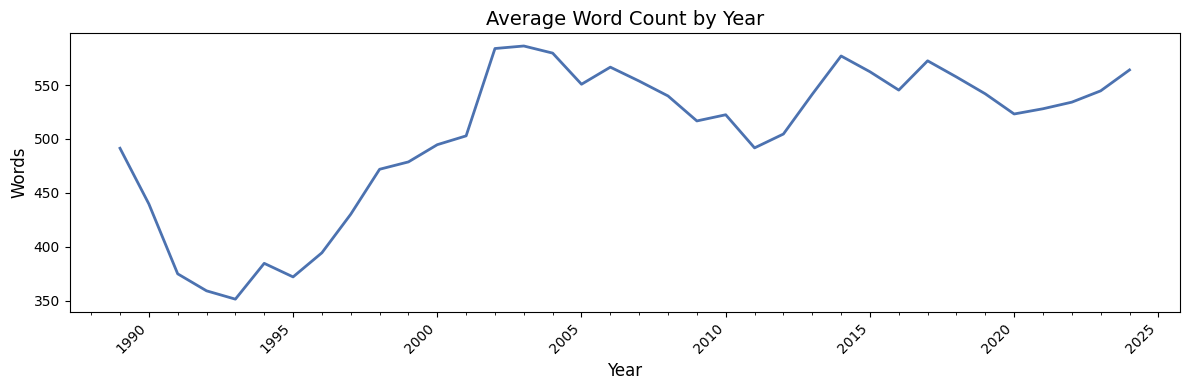

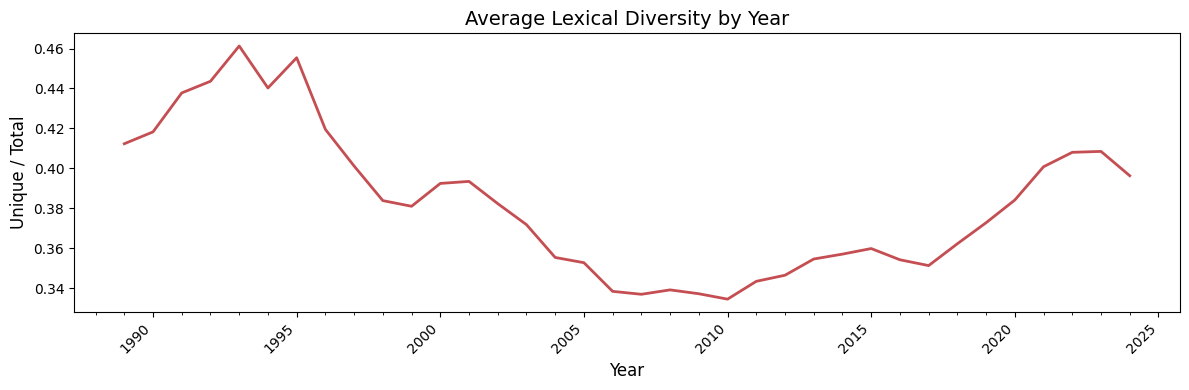

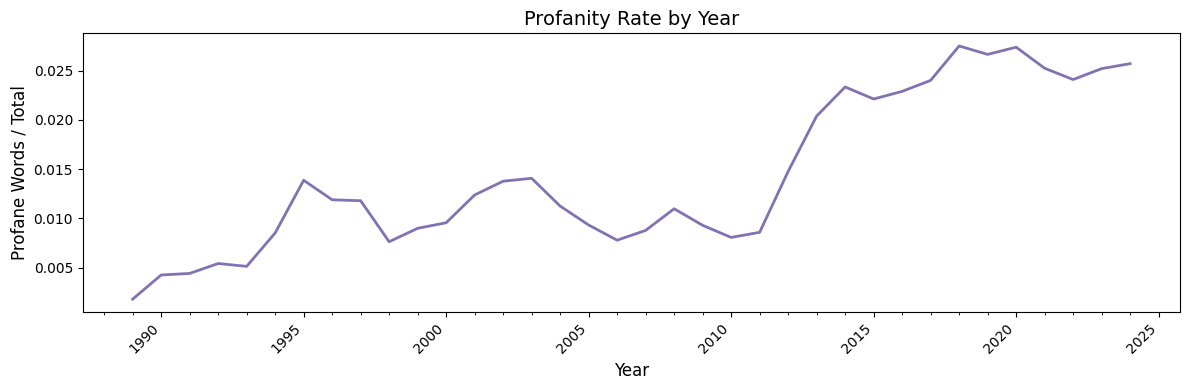

In [115]:
# Build year-level summary
rate_cols = [
    "word_count", "lexical_diversity",
    "profanity_rate",
    "pron_1s_rate", "pron_1p_rate", "pron_2_rate",
    "wealth_rate", "violence_rate", "politics_rate", "drugs_rate", "introspection_rate",
]
year_summary = (
    df.dropna(subset=["release_year"])
    .groupby("release_year")
    .agg(song_count=("title", "size"), **{c: (c, "mean") for c in rate_cols})
    .sort_index()
)

years = year_summary.index.tolist()


def smooth_series(column):
    """Apply a light centered rolling average for readability."""
    return year_summary[column].rolling(window=SMOOTH_WINDOW, center=True, min_periods=1).mean()


def year_line(column, title, color="#4C72B0", ylabel=None):
    """Draw a smoothed line chart of one metric across years."""
    _, ax = plt.subplots(figsize=(12, 4))
    ax.plot(years, smooth_series(column), color=color, linewidth=2.0)
    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel or column.replace("_", " ").title())
    ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

year_line("word_count", "Average Word Count by Year", "#4C72B0", "Words")
year_line("lexical_diversity", "Average Lexical Diversity by Year", "#C44E52", "Unique / Total")
year_line("profanity_rate", "Profanity Rate by Year", "#8172B2", "Profane Words / Total")

**Analysis**

The length of songs seem to gradually rise over time, but the quality of the diction clearly deteriorates from its peak in 1994. Interestingly enough, there seems to be a reversal of this trend since 2010 with Average Lexical Diversity recovering between 2010-2023.

The Profanity Rate plot speaks for itself - rappers increasingly rely on curse words and racial slurs in their craft. 

---
## 10 · Thematic Keyword Rates

This section is dedicated to thematic keyword-rate trends over time:
- Wealth / Luxury
- Violence / Crime
- Politics / Social Justice
- Drugs
- Introspection / Mental Health

All rates are plotted together for direct comparison.

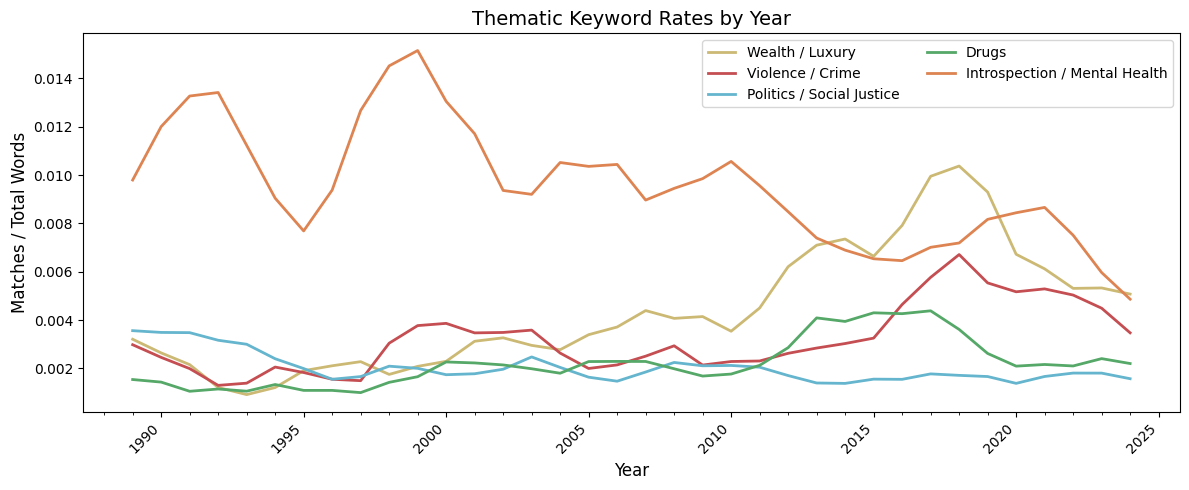

In [116]:
# Thematic trends by year — combined chart
_, ax = plt.subplots(figsize=(12, 5))
ax.plot(years, smooth_series("wealth_rate"), linewidth=2.0, label="Wealth / Luxury", color="#CCB974")
ax.plot(years, smooth_series("violence_rate"), linewidth=2.0, label="Violence / Crime", color="#C44E52")
ax.plot(years, smooth_series("politics_rate"), linewidth=2.0, label="Politics / Social Justice", color="#64B5CD")
ax.plot(years, smooth_series("drugs_rate"), linewidth=2.0, label="Drugs", color="#55A868")
ax.plot(years, smooth_series("introspection_rate"), linewidth=2.0, label="Introspection / Mental Health", color="#DD8452")
ax.set_title("Thematic Keyword Rates by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Matches / Total Words")
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha="right")
ax.legend(ncol=2)
plt.tight_layout()
plt.show()

**Analysis**

The subject of introspection and mental health has clearly trended down over time, giving way to themes of Wealth and Violence. 

It appears that over time, rap has grown more and more "themeless", demonstrating less focus in any one of the topics that I pre-constructed. More work can be done in this leg of the analysis. It's possible that other themes have emerged over time and not caputred in this analysis or that the words associated with each theme have changed over time. In both these cases, this analysis will not entirely capture how communication of these themes have evolved. 

---
## 11 · Pronoun Usage Trends

This section is dedicated to pronoun usage over time:
- First-person singular (`I / me / my`)
- First-person plural (`we / us / our`)
- Second person (`you / your`)

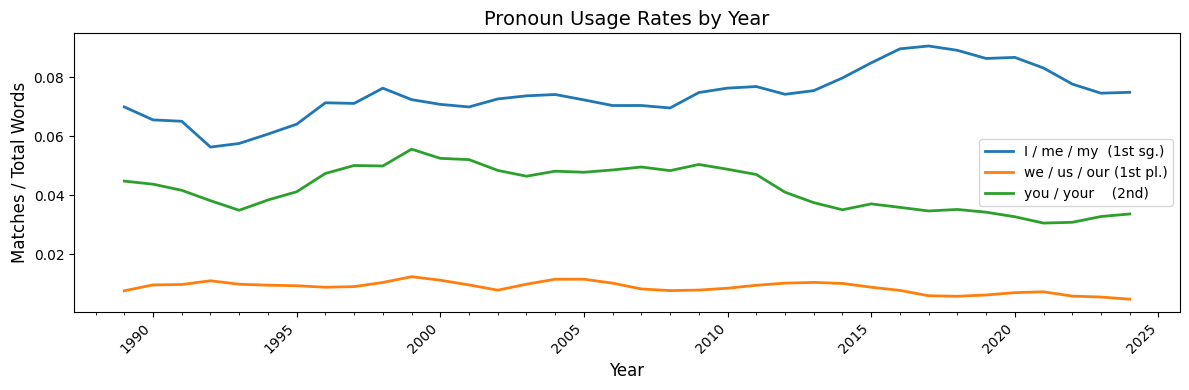

In [117]:
# Pronoun trends by year
_, ax = plt.subplots(figsize=(12, 4))
ax.plot(years, smooth_series("pron_1s_rate"), linewidth=2.0, label="I / me / my  (1st sg.)")
ax.plot(years, smooth_series("pron_1p_rate"), linewidth=2.0, label="we / us / our (1st pl.)")
ax.plot(years, smooth_series("pron_2_rate"), linewidth=2.0, label="you / your    (2nd)")
ax.set_title("Pronoun Usage Rates by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Matches / Total Words")
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_minor_locator(ticker.MultipleLocator(1))
plt.xticks(rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

**Analysis**

Not much to see here. Would be interesting to see how this compares to other genres of music. 

---
## 12 · Most Common Words by 5-Year Period

The top 10 highest-frequency words across all songs in each 5-year period (1989–2024), after filtering:
- NLTK English stopwords (articles, prepositions, common function words)
- A custom filler word list (`FILLER_WORDS`) — vocal sounds, colloquial connectors, and generic verbs that carry no thematic signal (*oh*, *la*, *yeah*, *like*, *gonna*, *man*, *go*, etc.)
- Tokens shorter than 3 characters

The 1989–1993 block is now included and explicitly labeled **Lower Confidence** because early-year coverage is comparatively sparse and can bias top-word frequencies. Treat this block as directional rather than definitive.

What remains is a snapshot of the vocabulary each era chose to repeat most — the words that defined the sound and substance of charting rap across 35 years.


In [120]:
TOP_N = 10

# Extra filler words not caught by nltk stopwords
FILLER_WORDS = {
    "oh", "la", "like", "yeah", "yea", "ay", "aye", "eh", "uh", "um",
    "ooh", "woah", "whoa", "yo", "na", "da", "ha", "huh", "mmm",
    "gonna", "gotta", "wanna", "cause", "'cause", "got", "get",
    "know", "said", "let", "come", "going", "go", "right", "back",
    "still", "never", "always", "every", "way", "time", "make",
    "look", "see", "tell", "say", "put", "take", "man", "one",
}

# Create 5-year periods including 1989-1993 (explicitly labeled lower confidence)
period_bins = [1989, 1994, 1999, 2004, 2009, 2014, 2019, 2025]
period_labels = [
    "1989-1993 (Lower Confidence)",
    "1994-1998",
    "1999-2003",
    "2004-2008",
    "2009-2013",
    "2014-2018",
    "2019-2024",
]
df_for_words = df[df["decade"] != "Unknown"].copy()
df_for_words["period"] = pd.cut(df_for_words["release_year"], bins=period_bins, labels=period_labels, right=False)

rows = []
for period, group in df_for_words.groupby("period"):
    all_words = []
    for text in group["lyrics_clean"]:
        all_words.extend(word_list(text))

    # Remove stopwords, filler words, and very short tokens
    filtered = [w for w in all_words if w not in STOPWORDS and w not in FILLER_WORDS and len(w) > 2]
    for word, cnt in Counter(filtered).most_common(TOP_N):
        rows.append({"period": period, "word": word, "count": cnt})

top_words = pd.DataFrame(rows)

# Display each period
for period in sorted(top_words["period"].unique()):
    print(f"\n{'='*40}")
    print(f"  {period}")
    print(f"{'='*40}")
    subset = top_words[top_words["period"] == period].reset_index(drop=True)
    subset.index += 1
    print(subset[["word", "count"]].to_string())



  1989-1993 (Lower Confidence)
         word  count
1        love    478
2        baby    443
3        dont    297
4        want    265
5        girl    230
6        give    225
7        cant    182
8        good    170
9       heart    162
10  everybody    157

  1994-1998
     word  count
1    dont    429
2    love    420
3    baby    406
4    want    300
5    shit    224
6   youre    221
7   could    211
8    keep    203
9    need    200
10   give    196

  1999-2003
     word  count
1    love    651
2    dont    627
3    baby    548
4    want    504
5    girl    376
6   nigga    329
7    shit    327
8    give    262
9    need    259
10    boy    247

  2004-2008
     word  count
1    dont    754
2    girl    681
3    love    636
4    baby    562
5    aint    502
6    want    487
7    give    389
8    cant    342
9     wit    308
10  nigga    268

  2009-2013
     word  count
1    baby    754
2    love    709
3    dont    556
4    girl    483
5    want    473
6    aint    353
7    

**Analysis**

I mean just look at this nonsense we see in 2019-2024...

"Love" - safely a top 3 word since 1989 - drops to ninth place in usage within the 2019-2024 half-decade. Instead we see profanity and racial slurs... and "ayy" taking 10th place. 

---
## 13 · Export

Two CSVs are written to `data/processed/`:

| File | Contents |
|------|----------|
| `rap_lyrics_cleaned.csv` | Song-level dataset with all computed metrics (including rhyme metrics) |
| `rap_lyrics_decade_summary.csv` | 5-year period averages (including rhyme metrics) |

These outputs can be loaded independently for further analysis, visualization tools, or other notebooks without re-running the full pipeline.

In [119]:
OUT_DIR = Path("data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

song_path   = OUT_DIR / "rap_lyrics_cleaned.csv"
decade_path = OUT_DIR / "rap_lyrics_decade_summary.csv"

df.to_csv(song_path, index=False)
print(f"Saved song-level data  -> {song_path}  ({len(df)} rows)")

period_summary.to_csv(decade_path)
print(f"Saved period summary   -> {decade_path}  ({len(period_summary)} rows)")

Saved song-level data  -> data/processed/rap_lyrics_cleaned.csv  (1788 rows)
Saved period summary   -> data/processed/rap_lyrics_decade_summary.csv  (7 rows)


---
## 14 · Next Steps

This notebook now covers vocabulary, profanity, pronouns, thematic language, and multiple rhyme metrics across 1989-2024. The strongest next improvements are about data quality, metric calibration, and interpretability.

**1) Improve data quality and coverage**
- **Targeted lyric backfill for sparse years**: prioritize 1989-1993 gaps first, then re-run the notebook to reduce early-period instability.
- **Fallback title cleanup**: normalize malformed fallback titles (for example slug-like variants) to reduce duplicate/noisy entries in early years.
- **Document unresolved metadata gaps**: keep a short table of songs still missing clean artist/title/year alignment.

**2) Calibrate rhyme metrics**
- **Manual validation sample**: hand-check a small stratified sample (for example 10 songs per era) to estimate precision/recall for:
  - `end_rhyme_rate`
  - `internal_rhyme_rate` (exploratory)
  - `end_self_or_unknown_rate`
- **Sensitivity checks**: compare results with and without repeated-word end pairs, and with stricter token filters, to see how trend shape changes.
- **Unknown-word audit**: inspect the most frequent out-of-dictionary line-end words to separate slang/creative spellings from noisy text artifacts.

**3) Expand explanatory power**
- **Artist-level and cohort views**: compare trends by major artist cohorts or debut eras, not just aggregate yearly means.
- **Regional/subgenre tags**: add lightweight labels (South, West Coast, trap, drill, conscious) to test whether shifts are global or scene-specific.
- **Event overlays**: annotate key industry/cultural windows on trend charts to improve interpretation.

**4) Strengthen outputs for reuse**
- **Add a compact methods appendix**: include metric formulas and caveats in one exportable markdown block.
- **Export yearly summaries**: save `year_summary` and `rhyme_year_summary` CSVs for downstream plotting tools.
- **Freeze a reproducible snapshot**: keep one dated processed dataset + notebook run to support class presentation and grading consistency.